# Check frozen core (AGFN)

Analogous to RxnFlow's `notebooks/06_check_frozen_core.ipynb`. We seed generation with a fixed
molecule whose **core is held immutable**, grow molecules from it, and verify the core stays
intact — and stays **identifiable** — throughout generation.

**How AGFN freezes the core.** AGFN builds molecules atom-by-atom on a `networkx` graph, assigning
each new atom the label `max(nodes)+1` and never renumbering. So the seed's atoms keep node labels
`0..N-1` for the whole trajectory. `build_frozen_seed_graph` stamps `g.graph['frozen_seed_size']`
and `g.graph['frozen_growth_sites']`; `graph_to_Data` masks any action that would edit the core, and
`GraphBuildingEnv.step` asserts the same as a safety net. This part is robust — Checks A and B pass.

**Why we tag the core (the fix).** The *graph* keeps stable labels, but `graph_to_mol` ends with a
canonical-SMILES round-trip (`MolFromSmiles(MolToSmiles(...))`) that **reorders RDKit atoms**, so an
atom's RDKit index in the emitted molecule is *not* its node label — and the reordering shifts as the
molecule grows. Highlighting `range(N)` therefore shades the wrong atoms. Mirroring RxnFlow, we make
core identity *chemical, not positional*: `graph_to_mol(g, tag_frozen=True)` stamps each core atom
with a reserved atom-map number `FROZEN_MAP_BASE + label` that survives the round-trip, and
`frozen_core_atoms(mol)` locates the core by that tag instead of by index.

Three checks per generated molecule:
- **Check A (exact):** the subgraph induced on labels `0..N-1` equals the seed (atoms, bonds, attrs).
- **Check B (chemistry):** `generated_mol.HasSubstructMatch(seed_mol)`, where `seed_mol` is the
  frozen core as the env represents it (`graph_to_mol(seed_graph)`), not a re-parse of the raw SMILES.
- **Check C (identity, across consecutive rollouts):** the atoms we *highlight* — located by map
  number — are exactly one of the seed's substructure matches, i.e. the red region equals the seed.

In [1]:
import os, sys

# Put the repo's src/ on the path whether this runs from notebooks/ or the repo root.
for cand in ('../src', 'src', '../../src'):
    p = os.path.abspath(cand)
    if os.path.isdir(os.path.join(p, 'gflownet')):
        sys.path.insert(0, p)
        break

import torch
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog('rdApp.*')

from agfn.sampling import Sampler
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

# Frozen-core identification helpers: locate the seed core in a grown molecule by its reserved
# atom-map tag (FROZEN_MAP_BASE + seed label), which survives graph_to_mol's canonical round-trip.
from gflownet.envs.mol_building_env import (
    frozen_core_atoms, frozen_core_index_map, strip_frozen_maps, FROZEN_MAP_BASE,
)

molbuildingenv.py c import error


/home/aid/dkoh/third_party/AGFN/src/gflownet/envs/mol_building_env.py:27: UserWarning: Could not import mol_graph_to_Data, Graph, GraphDef from _C, using pure python implementation
  warnings.warn("Could not import mol_graph_to_Data, Graph, GraphDef from _C, using pure python implementation")


## Configuration

`SEED_SMILES` must use only atoms in the checkpoint's atom set (`['Br','C','Cl','F','I','N','O','S']`) and be smaller than `max_nodes` (45) to leave room to
grow. `GROWTH_ATOMS` are the 0-based seed atom indices where new atoms may attach; every other
core atom is frozen. Set `GROWTH_ATOMS = None` to freeze the whole core but allow growth at any
atom, or swap to `FROZEN_ATOMS = [...]` to name the atoms to freeze instead.

In [38]:
CKPT = "/home/aid/dkoh/log/generative/trash/braf_RTB_Denovo_20260527_174606/model_state_braf_RTB_Denovo_20260527_174606_0.pt"
SEED_SMILES = "COC1=CC=C(F)C(F)=C1C(C=C2)=CN3C2=NC(NC([C@@H]4[C@@H](C)C4)=O)=C3"   # benzene; swap for any seed over the model's atom set
GROWTH_ATOMS = [22]          # grow only off atom 0; the other 5 ring atoms stay frozen
FROZEN_ATOMS = None         # alternative: name atoms to freeze instead (mutually exclusive)
N_SAMPLES = 128

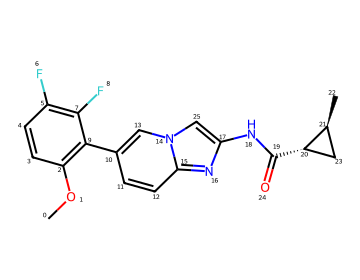

In [39]:
# 2D structure with each atom's index annotated — read off the numbers you want to freeze.
seed = Chem.MolFromSmiles(SEED_SMILES)
labeled = Chem.Mol(seed)
for atom in labeled.GetAtoms():
    atom.SetProp("atomNote", str(atom.GetIdx()))

d = rdMolDraw2D.MolDraw2DSVG(360, 280)
rdMolDraw2D.PrepareAndDrawMolecule(d, labeled)
d.FinishDrawing()
SVG(d.GetDrawingText())

In [40]:
sampler = Sampler(
    model_load_path=CKPT,
    initial_scaffold=SEED_SMILES,
    allowed_growth_atoms=GROWTH_ATOMS,
    frozen_atoms=FROZEN_ATOMS,
)
seed = sampler.seed_graph
N = seed.graph['frozen_seed_size']
growth_sites = seed.graph['frozen_growth_sites']
print(f'seed = {SEED_SMILES!r}: {N} core atoms, growth sites = {sorted(growth_sites)}')

# Reference molecule for the chemistry-level checks (B and C): the frozen core *as the env
# represents it*, i.e. graph_to_mol of the seed graph -- NOT a re-parse of the raw SMILES.
# build_frozen_seed_graph -> mol_to_graph keeps only {element, chirality, charge, explicit-H,
# no-implicit}; it deliberately drops parse artifacts such as radical electrons (e.g. an under-valent
# growth atom written as [C@@H] is rendered as a plain carbon that can grow). Those artifacts never
# appear in generated molecules, so matching against them yields false failures -- RDKit's default
# substructure matcher requires the query's radical count to be matched. The env seed is, by
# definition, exactly what was frozen, so it is the correct (and artifact-proof) reference.
seed_mol = sampler.ctx.graph_to_mol(sampler.seed_graph)
env_seed_canon = Chem.MolToSmiles(seed_mol)
raw_seed_canon = Chem.MolToSmiles(Chem.MolFromSmiles(SEED_SMILES))
print(f'frozen core (env reference): {env_seed_canon}')
if env_seed_canon != raw_seed_canon:
    print(f'note: raw SEED_SMILES canonicalizes to {raw_seed_canon!r}, which differs from the frozen\n'
          f'      core above -- the env normalized away a parse artifact (e.g. a radical at an\n'
          f'      under-valent growth atom). Checks B/C compare against the frozen core, as they should.')

[frozen-core] seed 'COC1=CC=C(F)C(F)=C1C(C=C2)=CN3C2=NC(NC([C@@H]4[C@@H](C)C4)=O)=C3': 26 core atoms, 1 growth site(s).
len loaded dict: 419
seed = 'COC1=CC=C(F)C(F)=C1C(C=C2)=CN3C2=NC(NC([C@@H]4[C@@H](C)C4)=O)=C3': 26 core atoms, growth sites = [22]
frozen core (env reference): COc1ccc(F)c(F)c1-c1ccc2nc(NC(=O)[C@H]3C[C@@H]3C)cn2c1


## Sample

Call `sample_from_model` directly (rather than `sample_smiles`) so we can inspect each final
trajectory **graph**, which Check A needs.

In [ ]:
cond = sampler.cond_info_cmp.compute_cond_info_forward(N_SAMPLES)
enc = sampler.cond_info_cmp.thermometer_encoding(cond).to(sampler.device)
with torch.no_grad():
    res = sampler.graph_sampler.sample_from_model(
        sampler.model, N_SAMPLES, enc, sampler.device,
        random_stop_action_prob=sampler.hps['random_stop_prob'],
        random_action_prob=sampler.hps['random_action_prob'],
        seed_graph=sampler.seed_graph,
    )

valid = [r for r in res if r['is_valid'] and 'fwd_logprob' in r]
graphs = [r['traj'][-1][0] for r in valid]
mols = [sampler.ctx.graph_to_mol(g) for g in graphs]                       # plain mols (Check B)
tagged_mols = [sampler.ctx.graph_to_mol(g, tag_frozen=True) for g in graphs]  # core tagged for ID/viz
grew = sum(len(g.nodes) > N for g in graphs)
print(f'valid trajectories: {len(valid)}/{N_SAMPLES}   |   grew beyond seed: {grew}/{len(graphs)}')

## Check A — exact core subgraph

Since seed atoms keep labels `0..N-1`, compare the induced subgraph on those labels (atoms,
bonds, and their attribute dicts) against the seed. This is the strict invariant the masks +
step guards enforce.

In [ ]:
def core_intact_graph(g):
    if not all(k in g.nodes for k in range(N)):
        return False
    for k in range(N):
        if dict(g.nodes[k]) != dict(seed.nodes[k]):
            return False
    seed_edges = {frozenset(e): dict(seed.edges[e]) for e in seed.edges if e[0] < N and e[1] < N}
    g_edges = {frozenset(e): dict(g.edges[e]) for e in g.edges if e[0] < N and e[1] < N}
    return seed_edges == g_edges

a_pass = sum(core_intact_graph(g) for g in graphs)
print(f'Check A (exact core subgraph): {a_pass}/{len(graphs)} = {100.0 * a_pass / max(len(graphs), 1):.1f}%')

## Check B — RDKit substructure match

A chemistry-level cross-check: the generated molecule must contain the seed as a substructure.

The reference `seed_mol` is the frozen core **as the env represents it** (`graph_to_mol(seed_graph)`,
defined in the sampler cell), not a re-parse of the raw `SEED_SMILES`. The raw SMILES can carry RDKit
parse artifacts — e.g. an under-valent growth atom written as `[C@@H]` becomes a **carbon radical** —
that `mol_to_graph` intentionally drops and that therefore never appear in generated molecules.
Matching against such an artifact gives false failures (RDKit's default matcher requires the query's
radical count to be matched), so we compare against exactly what was frozen.

In [ ]:
# seed_mol is the env's rendering of the frozen core (defined in the sampler cell), not a re-parse
# of the raw SMILES -- see that cell for why (input SMILES can carry parse artifacts the env drops).
b_pass = sum(m is not None and m.HasSubstructMatch(seed_mol) for m in mols)
print(f'Check B (substructure match): {b_pass}/{len(mols)} = {100.0 * b_pass / max(len(mols), 1):.1f}%')

## Check C — labeled core == seed across consecutive rollouts

The decisive check for this notebook's purpose. We roll out **several independent sampling
batches** and, for each generated molecule, locate the core the way the visualization does — by
the reserved atom-map tag, via `frozen_core_atoms` — then confirm that set of atoms is **exactly
one of the seed's substructure matches**. That ties the highlighted (red) region to the seed
chemically, so a pass means the red atoms in the pictures below really are the seed molecule,
not an index that happens to line up. We expect 100% in every round.

As in Check B, the `seed_mol` reference is the env's frozen core (`graph_to_mol(seed_graph)`), so the
match is against exactly what was frozen rather than a re-parse of the raw SMILES.

In [ ]:
# Re-sample several independent batches and confirm, for every grown molecule, that the atoms we
# would HIGHLIGHT -- located by reserved map number, not by index -- are exactly the seed.
def rollout(n):
    cond = sampler.cond_info_cmp.compute_cond_info_forward(n)
    enc = sampler.cond_info_cmp.thermometer_encoding(cond).to(sampler.device)
    with torch.no_grad():
        res = sampler.graph_sampler.sample_from_model(
            sampler.model, n, enc, sampler.device,
            random_stop_action_prob=sampler.hps['random_stop_prob'],
            random_action_prob=sampler.hps['random_action_prob'],
            seed_graph=sampler.seed_graph,
        )
    return [r['traj'][-1][0] for r in res if r['is_valid'] and 'fwd_logprob' in r]

ROUNDS = 3
# seed_mol = the env's rendering of the frozen core (defined in the sampler cell); see there for why
# we do not re-parse the raw SMILES.
total = c_count = c_redseed = grew_c = 0

failure_modes = []
success_modes = []

for rd in range(ROUNDS):
    for g in rollout(N_SAMPLES):
        m = sampler.ctx.graph_to_mol(g, tag_frozen=True)
        core = frozen_core_atoms(m)                                   # the atoms we highlight
        total += 1
        grew_c += len(g.nodes) > N
        # exactly N core atoms, and their map numbers recover the seed labels 0..N-1
        if len(core) == N and sorted(frozen_core_index_map(m).values()) == list(range(N)):
            c_count += 1
        # the highlighted set IS one of the seed's substructure matches => red == seed
        # print(Chem.MolToSmiles(m), m.GetSubstructMatches(seed_mol))
        if set(core) in [set(mt) for mt in m.GetSubstructMatches(seed_mol)]:
            c_redseed += 1
            success_modes.append((m, seed_mol))
        else:
            failure_modes.append((m, seed_mol))
    print(f'round {rd + 1}: cumulative {total} mols | exact-N core {c_count} | red==seed {c_redseed}')

print(f'\nCheck C across {ROUNDS} rollouts ({total} molecules, {grew_c} grew beyond seed):')
print(f'  highlighted core has all N seed atoms : {c_count}/{total}')
print(f'  highlighted core == seed substructure : {c_redseed}/{total}')
assert total > 0 and c_count == total == c_redseed, 'labeled core does not match the seed somewhere!'
print('\nPASS: the labeled (red) core equals the seed molecule in every sampled molecule.')

In [ ]:
pairs = success_modes

def strip_maps(mol):
    m = Chem.Mol(mol)                 # copy -> originals untouched
    for atom in m.GetAtoms():
        atom.SetAtomMapNum(0)         # 0 == "no map number"
    return m

flat = [strip_maps(m) for pair in pairs for m in pair]
legends = [lbl for i in range(len(pairs)) for lbl in (f"mol {i}", f"seed {i}")]

img = Draw.MolsToGridImage(flat, molsPerRow=2, subImgSize=(300, 300), legends=legends)
# img

## Summary

In [54]:
print(f'valid              : {len(valid)}/{N_SAMPLES}')
print(f'grew beyond seed   : {grew}/{len(graphs)}')
print(f'Check A (exact)    : {a_pass}/{len(graphs)}')
print(f'Check B (substr)   : {b_pass}/{len(mols)}')
print(f'Check C (red==seed): {c_redseed}/{total}  (across {ROUNDS} consecutive rollouts)')
assert len(graphs) > 0, 'no valid molecules generated'
assert a_pass == len(graphs), 'frozen core was edited in at least one molecule!'
assert c_redseed == total, 'labeled core != seed in at least one molecule!'
print('\nPASS: every generated molecule kept the frozen core intact, and the labeled core is the seed.')

valid              : 128/128
grew beyond seed   : 128/128
Check A (exact)    : 128/128
Check B (substr)   : 128/128
Check C (red==seed): 384/384  (across 3 consecutive rollouts)

PASS: every generated molecule kept the frozen core intact, and the labeled core is the seed.


## Visualize

A few grown molecules with the frozen core highlighted. We locate the core by its reserved
atom-map number (`FROZEN_MAP_BASE + label`), recovered with `frozen_core_atoms`, because
`graph_to_mol`'s canonical round-trip reorders atoms — the core is **not** at RDKit indices
`0..N-1`. The map tags are cleared for a clean depiction (same atom order), and each atom is
annotated with its original seed index.

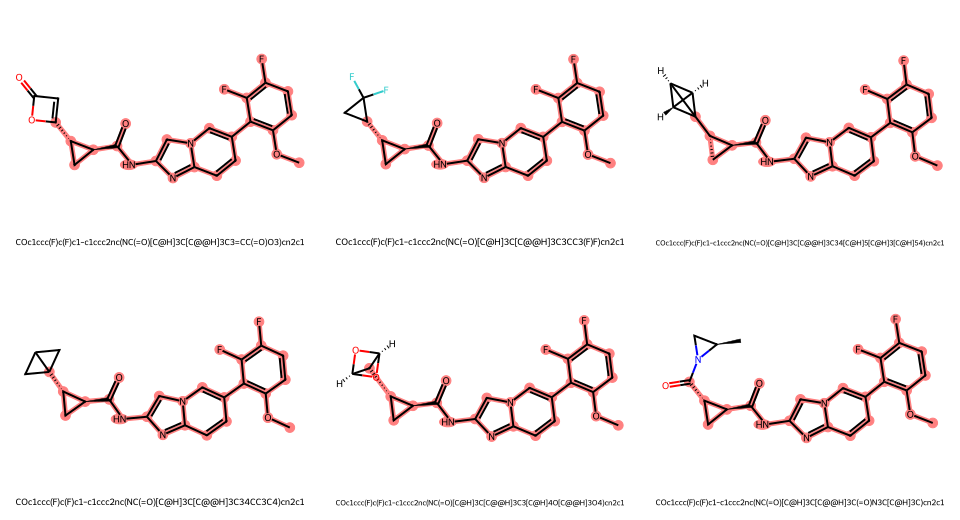

In [55]:
# Grid of grown molecules with the frozen core highlighted. Core atoms are located by their map
# number (rides through graph_to_mol's reordering round-trip), NOT assumed to be indices 0..N-1.
tagged_show = [m for m in tagged_mols if m is not None and m.GetNumAtoms() > N][:6]
highlights, clean, legends = [], [], []
for m in tagged_show:
    highlights.append(frozen_core_atoms(m))      # the seed atoms, by map number
    d = Chem.Mol(m)
    for a in d.GetAtoms():
        a.SetAtomMapNum(0)                       # clean labels, identical atom order -> same indices
    clean.append(d)
    legends.append(Chem.MolToSmiles(strip_frozen_maps(m)))
img = Draw.MolsToGridImage(
    clean,
    molsPerRow=3,
    subImgSize=(320, 260),
    highlightAtomLists=highlights,
    legends=legends,
    useSVG=False,
)
# MolsToGridImage may return a PIL.Image (.save) or an IPython Image (.data) depending on env.
if hasattr(img, 'save'):
    img.save('check_frozen_core_grid.png')
elif hasattr(img, 'data'):
    open('check_frozen_core_grid.png', 'wb').write(img.data)
img

In [56]:
# Per-molecule SVGs: highlight the core (located by map number) and annotate each core atom with
# its ORIGINAL seed index (recovered from the map number), wherever it landed after the round-trip.
tagged_show = [m for m in tagged_mols if m is not None and m.GetNumAtoms() > N][:6]
imgs = []
for m in tagged_show:
    core = frozen_core_atoms(m)
    imap = frozen_core_index_map(m)              # rdkit idx -> original seed index
    d_mol = Chem.Mol(m)
    for a in d_mol.GetAtoms():
        if a.GetIdx() in imap:
            a.SetProp("atomNote", str(imap[a.GetIdx()]))
        a.SetAtomMapNum(0)                       # clear tags for a clean depiction (same order)

    d = rdMolDraw2D.MolDraw2DSVG(360, 280)
    rdMolDraw2D.PrepareAndDrawMolecule(d, d_mol, highlightAtoms=core)
    d.FinishDrawing()
    imgs.append(SVG(d.GetDrawingText()))

In [57]:
# The core is NOT at indices 0..N-1: each grown molecule's core lands wherever the canonical
# round-trip placed it -- which is exactly why we locate it by map number.
print("range(N)            :", list(range(N)))
for i, m in enumerate(tagged_show):
    print(f"core idx (mol {i})   :", frozen_core_atoms(m))

range(N)            : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
core idx (mol 0)   : [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
core idx (mol 1)   : [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
core idx (mol 2)   : [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
core idx (mol 3)   : [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
core idx (mol 4)   : [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
core idx (mol 5)   : [4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [50]:
imgs

[<IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>]

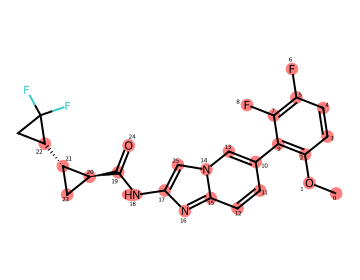

In [51]:
imgs[1]